# cGAN Training

### Goal - To build and train our **conditional GAN (cGAN)** - a generative model that learsn to create **synthetic handwriting images** conditioned on digit labels

## Plan 

1. Understand the architecture of a **conditional Gan (cGAN)**
2. Implement **Generator** and **discriminator** in pytorch
3. Train model with adversarial objectives
4. Visualise class-conditional handwriting samples

## Recap (cGAN)

A **Generative Adversarial Network (GAN)** consists of:
- A **Generator (G)** that creates fake samples from random noise.
- A **Discriminator (D)** that tries to tell real from fake.

In a **Conditional GAN**, both G and D receive an **additional input**: a *class label*.  
This allows the model to generate specific digits or characters on demand.

In [1]:
# import core libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

import os
import sys

from data_utils.dataloader import get_mnist_loaders
from model.cgan import Generator, Discriminator
from training.train_cgan import train_cgan
from utils.visualize import show_batch
from utils.checkpoint import save_checkpoint

device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)

print(f"Running on device: {device}")

Running on device: cuda


### Define Model Hyperparameters 


We’ll use a low-dimensional latent space (`z_dim = 100`),  
and condition the model on **10 digit classes (0–9)**.

GANs are notoriously sensitive to hyperparameters —  
we’ll start simple and iterate.

In [2]:
# hyperparameters 
z_dim = 100
num_classes = 10
img_shape = (1, 28, 28)
batch_size = 128
lr = 0.0002
epochs = 50

In [4]:
# Extract the data
# Load MNIST train and test dataloaders using the helper function

train_loader, test_loader = get_mnist_loaders(batch_size=batch_size)

# Inspect one batch to verify shape and labels
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Min pixel value:", images.min().item())
print("Max pixel value:", images.max().item())
print("Sample labels:", labels[:10])

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 39.3MB/s]


Extracting ../data/MNIST/raw/train-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]

Extracting ../data/MNIST/raw/train-labels-idx1-ubyte.gz to ../data/MNIST/raw



...

100%|██████████| 1.65M/1.65M [00:00<00:00, 10.4MB/s]


Extracting ../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 8.78MB/s]

Extracting ../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/MNIST/raw



Images shape: torch.Size([128, 1, 28, 28])
Labels shape: torch.Size([128])
Min pixel value: -1.0
Max pixel value: 1.0
Sample labels: tensor([5, 1, 7, 3, 1, 6, 6, 2, 4, 3])


Before we dive into training, let's define both our **Generator** and **Discriminator**.

Each will use the label embedding trick — where we turn the class label (e.g., “3”) into a learnable vector that can be concatenated with the noise or image input.

Our models are intentionally **lightweight** to make training on CPU/MPS feasible.  We’ll focus on the learning process and class conditioning rather than pixel-perfect realism.

In [5]:
# Initialize Generator and Discriminator

generator = Generator(
    z_dim=z_dim,
    num_classes=num_classes,
    img_shape=img_shape
).to(device)

discriminator = Discriminator(
    num_classes=num_classes,
    img_shape=img_shape
).to(device)

# Standard GAN minimax objective using Binary Cross Entropy loss
criterion = nn.BCELoss()

# Adam optimizers commonly used for GAN training
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

print(generator)
print(discriminator)

Generator(
  (label_emb): Embedding(10, 10)
  (model): Sequential(
    (0): Linear(in_features=110, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=256, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Linear(in_features=512, out_features=784, bias=True)
    (9): Tanh()
  )
)
Discriminator(
  (label_emb): Embedding(10, 10)
  (model): Sequential(
    (0): Linear(in_features=794, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## Training Strategy

We’ll alternate between training the **Discriminator (D)** and **Generator (G)**.

1. **Train D:**  
   - Use real images labeled as 1  
   - Use fake images (from G) labeled as 0  

2. **Train G:**  
   - Generate fake images  
   - Fool D into predicting them as 1  

This adversarial game continues until G generates *realistic*, class-conditioned digits.

In [7]:
# 1. Implement training loop
# 2. Save D & G every 10 epochs

import os

checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

generator.train()
discriminator.train()

g_losses = []
d_losses = []

for epoch in range(epochs):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        batch_size_current = imgs.size(0)

        # Labels for real and fake images
        valid = torch.ones(batch_size_current, 1, device=device)
        fake = torch.zeros(batch_size_current, 1, device=device)

        # -----------------------------
        # 1. Train Generator
        # -----------------------------
        optimizer_G.zero_grad()

        z = torch.randn(batch_size_current, z_dim, device=device)
        gen_labels = torch.randint(
            0,
            num_classes,
            (batch_size_current,),
            device=device
        )

        gen_imgs = generator(z, gen_labels)

        # Generator tries to fool the discriminator
        g_loss = criterion(discriminator(gen_imgs, gen_labels), valid)

        g_loss.backward()
        optimizer_G.step()

        # -----------------------------
        # 2. Train Discriminator
        # -----------------------------
        optimizer_D.zero_grad()

        # Loss on real images
        real_loss = criterion(discriminator(imgs, labels), valid)

        # Loss on fake images
        # detach() prevents updating the generator during discriminator training
        fake_loss = criterion(
            discriminator(gen_imgs.detach(), gen_labels),
            fake
        )

        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()

    avg_g_loss = epoch_g_loss / len(train_loader)
    avg_d_loss = epoch_d_loss / len(train_loader)

    g_losses.append(avg_g_loss)
    d_losses.append(avg_d_loss)

    print(
        f"[Epoch {epoch + 1}/{epochs}] "
        f"D loss: {avg_d_loss:.4f} | "
        f"G loss: {avg_g_loss:.4f}"
    )

    # Save Generator and Discriminator every 10 epochs
    if (epoch + 1) % 10 == 0:
        generator_path = os.path.join(
            checkpoint_dir,
            f"cgan_generator_epoch_{epoch + 1}.pt"
        )

        discriminator_path = os.path.join(
            checkpoint_dir,
            f"cgan_discriminator_epoch_{epoch + 1}.pt"
        )

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": generator.state_dict(),
                "optimizer_state_dict": optimizer_G.state_dict(),
                "g_loss": avg_g_loss,
            },
            generator_path
        )

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": discriminator.state_dict(),
                "optimizer_state_dict": optimizer_D.state_dict(),
                "d_loss": avg_d_loss,
            },
            discriminator_path
        )

        print(f"Saved Generator checkpoint: {generator_path}")
        print(f"Saved Discriminator checkpoint: {discriminator_path}")

[Epoch 1/50] D loss: 0.4801 | G loss: 1.0179
[Epoch 2/50] D loss: 0.4308 | G loss: 1.3343
[Epoch 3/50] D loss: 0.4264 | G loss: 1.4458
[Epoch 4/50] D loss: 0.4188 | G loss: 1.4874
[Epoch 5/50] D loss: 0.4194 | G loss: 1.5189
[Epoch 6/50] D loss: 0.4064 | G loss: 1.6025
[Epoch 7/50] D loss: 0.4006 | G loss: 1.6148
[Epoch 8/50] D loss: 0.3892 | G loss: 1.6665
[Epoch 9/50] D loss: 0.3794 | G loss: 1.7039
[Epoch 10/50] D loss: 0.3695 | G loss: 1.8039
Saved Generator checkpoint: checkpoints/cgan_generator_epoch_10.pt
Saved Discriminator checkpoint: checkpoints/cgan_discriminator_epoch_10.pt
[Epoch 11/50] D loss: 0.3512 | G loss: 1.8651
[Epoch 12/50] D loss: 0.3843 | G loss: 1.7216
[Epoch 13/50] D loss: 0.3791 | G loss: 1.7633
[Epoch 14/50] D loss: 0.3651 | G loss: 1.8558
[Epoch 15/50] D loss: 0.3672 | G loss: 1.8850
[Epoch 16/50] D loss: 0.3595 | G loss: 1.8787
[Epoch 17/50] D loss: 0.3466 | G loss: 1.8757
[Epoch 18/50] D loss: 0.3695 | G loss: 1.8294
[Epoch 19/50] D loss: 0.3449 | G loss: 

In [8]:
# Save final trained cGAN models

import os

checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

torch.save(
    {
        "model_state_dict": generator.state_dict(),
        "optimizer_state_dict": optimizer_G.state_dict(),
        "g_losses": g_losses,
    },
    os.path.join(checkpoint_dir, "cgan_generator_final.pt")
)

torch.save(
    {
        "model_state_dict": discriminator.state_dict(),
        "optimizer_state_dict": optimizer_D.state_dict(),
        "d_losses": d_losses,
    },
    os.path.join(checkpoint_dir, "cgan_discriminator_final.pt")
)

print("Final Generator saved at:", os.path.join(checkpoint_dir, "cgan_generator_final.pt"))
print("Final Discriminator saved at:", os.path.join(checkpoint_dir, "cgan_discriminator_final.pt"))

Final Generator saved at: checkpoints/cgan_generator_final.pt
Final Discriminator saved at: checkpoints/cgan_discriminator_final.pt


### Note
Training GANs can be unstable.  
If losses oscillate, that’s expected — D and G are in constant competition.

Let’s visualize a few generated samples at the end of training to check if conditioning worked.

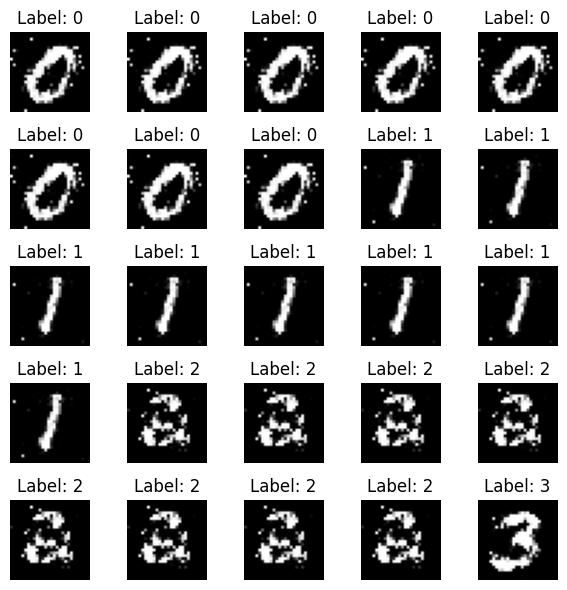

In [9]:
### Generate and visualize samples
def generate_samples(generator, n_classes=10, n_per_class=8):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_classes * n_per_class, z_dim).to(device)
        labels = torch.tensor([i for i in range(n_classes) for _ in range(n_per_class)]).to(device)
        gen_imgs = generator(z, labels)
    generator.train()
    return gen_imgs, labels

gen_imgs, gen_labels = generate_samples(generator)
show_batch(gen_imgs.cpu(), gen_labels.cpu(), n=25)

We can now see grids of digits 0–9, each set showing several synthetic examples.  
Each class label corresponds to the digit the Generator was conditioned on.

Even if the images look a bit fuzzy, the model has learned the *concept* of conditioning —  
the generator “knows” which class to produce.